# Predição de Faixa Salarial de Profissionais de Dados no Brasil com Machine Learning

**FATEC Jundiaí - Dep. de Tecnologia**  
**Disciplina**: Inteligência Computacional  
**Professor**: Me. Mateus Guilherme Fuini  
**Autores**:
* Rodolfo Vinicius Cima Takemoto
* Tiago Galhardo Avelar

---

### Resumo do Projeto
Este projeto acadêmico de Ciência de Dados visa construir um modelo preditivo baseado em Aprendizado de Máquina Supervisionado (Classificação) para prever a faixa salarial de profissionais de dados no Brasil. O conjunto de dados utilizado é o **State of Data Brazil 2024-2025**, o maior mapeamento do mercado de trabalho de dados no país. A variável-alvo original de remuneração foi simplificada em três faixas de salário (Baixa, Média e Alta) para representar diferentes perfis de maturidade profissional. O projeto adota boas práticas de Ciência de Dados, com foco especial na prevenção de vazamento de dados (*data leakage*) e explicabilidade das variáveis preditoras selecionadas.


## Configuração para execução no Google Colab e importação via Kaggle

Esta seção configura o ambiente, instala a biblioteca `kagglehub` se necessário, gerencia os caminhos do projeto e carrega as bibliotecas fundamentais do ecossistema Python para manipulação de dados (`pandas`, `numpy`), visualização estatística (`matplotlib`, `seaborn`) e modelagem de aprendizado de máquina (`scikit-learn`).

In [1]:
import os
import shutil
import sys
import subprocess
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.base import BaseEstimator, TransformerMixin

# Configurações globais de visualização
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

def is_colab():
    try:
        import google.colab
        return True
    except ImportError:
        return False

# Mudar diretório atual para a raiz do projeto se executando localmente na pasta 'notebooks'
if not is_colab() and Path(os.getcwd()).name == "notebooks":
    os.chdir("..")

# Criar pastas do projeto
Path("data/raw").mkdir(parents=True, exist_ok=True)
Path("data/processed").mkdir(parents=True, exist_ok=True)
Path("reports/figures").mkdir(parents=True, exist_ok=True)

print("Diretório atual:")
print(os.getcwd())

# Instalar kagglehub se necessário
try:
    import kagglehub
except ImportError:
    print("Instalando kagglehub...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "kagglehub"])
    import kagglehub

class IQRCapper(BaseEstimator, TransformerMixin):
    def __init__(self, factor=1.5):
        self.factor = factor
        self.lower_bounds_ = None
        self.upper_bounds_ = None

    def fit(self, X, y=None):
        if isinstance(X, pd.DataFrame):
            self.lower_bounds_ = {}
            self.upper_bounds_ = {}
            for col in X.columns:
                q1 = X[col].quantile(0.25)
                q3 = X[col].quantile(0.75)
                iqr = q3 - q1
                self.lower_bounds_[col] = q1 - self.factor * iqr
                self.upper_bounds_[col] = q3 + self.factor * iqr
        else:
            X_arr = np.asarray(X)
            q1 = np.percentile(X_arr, 25, axis=0)
            q3 = np.percentile(X_arr, 75, axis=0)
            iqr = q3 - q1
            self.lower_bounds_ = q1 - self.factor * iqr
            self.upper_bounds_ = q3 + self.factor * iqr
        return self

    def transform(self, X):
        if isinstance(X, pd.DataFrame):
            X_out = X.copy()
            for col in X.columns:
                X_out[col] = X_out[col].clip(
                    lower=self.lower_bounds_[col],
                    upper=self.upper_bounds_[col]
                )
            return X_out
        else:
            X_arr = np.asarray(X)
            return np.clip(X_arr, self.lower_bounds_, self.upper_bounds_)

def load_csv_with_encoding(csv_path):
    encodings = ["utf-8", "utf-8-sig", "latin1", "cp1252"]
    last_error = None

    for encoding in encodings:
        try:
            df = pd.read_csv(csv_path, encoding=encoding)
            print("Arquivo carregado com sucesso.")
            print(f"Caminho utilizado: {csv_path}")
            print(f"Encoding utilizado: {encoding}")
            print(f"Dimensões do dataset: {df.shape[0]} linhas e {df.shape[1]} colunas.")
            return df
        except Exception as error:
            last_error = error

    raise RuntimeError(f"Não foi possível carregar o CSV. Último erro: {last_error}")

def choose_best_csv(csv_files):
    if not csv_files:
        raise FileNotFoundError("Nenhum arquivo CSV foi encontrado.")

    priority_terms = [
        "state of data",
        "df_survey",
        "survey",
        "2024",
        "kaggle"
    ]

    scored_files = []

    for file in csv_files:
        name = file.name.lower()
        score = sum(1 for term in priority_terms if term in name)
        scored_files.append((score, file))

    scored_files.sort(key=lambda item: item[0], reverse=True)

    print("Arquivos CSV encontrados:")
    for index, (_, file) in enumerate(scored_files, start=1):
        print(f"{index}. {file}")

    selected_file = scored_files[0][1]
    print(f"Arquivo CSV escolhido: {selected_file}")

    return selected_file

def load_local_raw_dataset():
    raw_dir = Path("data/raw")
    csv_files = list(raw_dir.rglob("*.csv")) if raw_dir.exists() else []

    if not csv_files:
        return None

    print("CSV local encontrado em data/raw/.")
    selected_csv = choose_best_csv(csv_files)
    return load_csv_with_encoding(selected_csv)

def manual_upload_fallback():
    if not is_colab():
        raise FileNotFoundError(
            "Não foi possível baixar o dataset pelo KaggleHub e o ambiente atual não é Google Colab. "
            "Configure a autenticação do Kaggle ou coloque o CSV em data/raw/."
        )

    print("Não foi possível carregar automaticamente pelo KaggleHub.")
    print("Faça upload manual do arquivo CSV baixado do Kaggle.")

    from google.colab import files

    uploaded = files.upload()

    if len(uploaded) == 0:
        raise FileNotFoundError("Nenhum arquivo foi enviado.")

    csv_candidates = []

    for uploaded_filename in uploaded.keys():
        uploaded_path = Path(uploaded_filename)

        if uploaded_path.suffix.lower() == ".csv":
            destination_path = Path("data/raw") / uploaded_filename
            shutil.copy(uploaded_path, destination_path)
            csv_candidates.append(destination_path)

    if not csv_candidates:
        raise FileNotFoundError("Nenhum arquivo CSV foi enviado.")

    selected_csv = choose_best_csv(csv_candidates)

    return load_csv_with_encoding(selected_csv)

def load_state_of_data_dataset():
    dataset_slug = "datahackers/state-of-data-brazil-20242025"

    local_df = load_local_raw_dataset()
    if local_df is not None:
        return local_df

    try:
        try:
            import kagglehub
        except ImportError:
            print("Instalando kagglehub...")
            import sys
            import subprocess
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "kagglehub"])
            import kagglehub

        print(f"Tentando carregar dataset pelo KaggleHub: {dataset_slug}")

        dataset_path = Path(kagglehub.dataset_download(dataset_slug))

        print(f"Caminho retornado pelo KaggleHub: {dataset_path}")

        csv_files = list(dataset_path.rglob("*.csv"))

        selected_csv = choose_best_csv(csv_files)

        destination_path = Path("data/raw") / selected_csv.name

        if not destination_path.exists():
            shutil.copy(selected_csv, destination_path)

        return load_csv_with_encoding(destination_path)

    except Exception as error:
        print("Falha ao carregar o dataset via KaggleHub.")
        print(f"Erro encontrado: {error}")
        return manual_upload_fallback()


Diretório atual:
C:\Users\takem\.gemini\antigravity\scratch\state-of-data-salary-prediction


C:\Users\takem\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Carregamento dos Dados

Carregamos o arquivo CSV bruto contendo as respostas da pesquisa através da nossa função de download e importação. O dataset é baixado automaticamente do Kaggle pelo KaggleHub ou carregado via upload manual se necessário.

In [2]:
df_raw = load_state_of_data_dataset()
df_raw.head()

Tentando carregar dataset pelo KaggleHub: datahackers/state-of-data-brazil-20242025


Caminho retornado pelo KaggleHub: C:\Users\takem\.cache\kagglehub\datasets\datahackers\state-of-data-brazil-20242025\versions\1
Arquivos CSV encontrados:
1. C:\Users\takem\.cache\kagglehub\datasets\datahackers\state-of-data-brazil-20242025\versions\1\Final Dataset - State of Data 2024 - Kaggle - df_survey_2024.csv
Arquivo CSV escolhido: C:\Users\takem\.cache\kagglehub\datasets\datahackers\state-of-data-brazil-20242025\versions\1\Final Dataset - State of Data 2024 - Kaggle - df_survey_2024.csv


Arquivo carregado com sucesso.
Caminho utilizado: data\raw\Final Dataset - State of Data 2024 - Kaggle - df_survey_2024.csv
Encoding utilizado: utf-8
Dimensões do dataset: 5217 linhas e 403 colunas.


,0.a_token,0.d_data/hora_envio,1.a_idade,1.a.1_faixa_idade,1.b_genero,1.c_cor/raca/etnia,1.d_pcd,1.e_experiencia_profissional_prejudicada,1.e.1_Não acredito que minha experiência profissional seja afetada,"1.e.2_Sim, devido a minha Cor/Raça/Etnia",...,"8.d.3_Entrando em contato com os times de negócio para definição do problema, identificar a solução e apresentação de resultados.",8.d.4_Desenvolvendo modelos de Machine Learning com o objetivo de colocar em produção em sistemas (produtos de dados).,"8.d.5_Colocando modelos em produção, criando os pipelines de dados, APIs de consumo e monitoramento.","8.d.6_Cuidando da manutenção de modelos de Machine Learning já em produção, atuando no monitoramento, ajustes e refatoração quando necessário.","8.d.7_Realizando construções de dashboards em ferramentas de BI como PowerBI, Tableau, Looker, Qlik, etc.","8.d.8_Utilizando ferramentas avançadas de estatística como SAS, SPSS, Stata etc, para realizar análises.","8.d.9_Criando e dando manutenção em ETLs, DAGs e automações de pipelines de dados.",8.d.10_Criando e gerenciando soluções de Feature Store e cultura de MLOps.,"8.d.11_Criando e mantendo a infra que meus modelos e soluções rodam (clusters, servidores, API, containers, etc.)",8.d.12_Treinando e aplicando LLM's para solucionar problemas de negócio.
0,reb94rv0msth7q4nreb94riaq80iz3yi,16/10/2024 11:19:17,18,17-21,Masculino,Branca,Não,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1zc66g69jjt49y32l1zc66g8wqj79m4e,16/10/2024 20:45:31,18,17-21,Masculino,Branca,Não,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,uu99wmam4n5kc2uu99wmydf0rk7l58f7,17/10/2024 18:10:59,18,17-21,Masculino,Parda,Não,Não acredito que minha experiência profissiona...,1.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3ynsw7z0hl5hhpbfvaeqk73ynsw7z04l,22/10/2024 18:03:00,18,17-21,Masculino,Branca,Não,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,v6bji2ct5xckpl1uouv6bjiotkrf3b4f,23/10/2024 01:33:23,18,17-21,Masculino,Branca,Não,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Inspeção das Colunas e Seleção de Variáveis Relevantes

O dataset do State of Data possui mais de 400 colunas correspondentes às respostas do questionário. Para a nossa modelagem preditiva, selecionamos um subconjunto de colunas relevantes contendo informações do perfil profissional, formação escolar, cargo, senioridade, localização física, modelo de trabalho, além das ferramentas e tecnologias utilizadas no dia a dia. 

A variável-alvo salarial foi identificada sob a coluna original `2.h_faixa_salarial`. As colunas preditoras selecionadas incluem aspectos demográficos (gênero, região, escolaridade) e de trabalho (cargo, nível, setor, tamanho da empresa e se atua como gestor).

Para contornar eventuais caracteres especiais corrompidos nos nomes das colunas, realizamos o mapeamento dinâmico via correspondência de prefixo:


In [3]:
columns = list(df_raw.columns)
col_mapping = {}

for col in columns:
    if col.startswith("1.b_"):
        col_mapping[col] = "genero"
    elif col.startswith("1.l_"):
        col_mapping[col] = "escolaridade"
    elif col.startswith("1.i.2_"):
        col_mapping[col] = "regiao"
    elif col.startswith("2.a_"):
        col_mapping[col] = "situacao_trabalho"
    elif col.startswith("2.b_"):
        col_mapping[col] = "setor"
    elif col.startswith("2.c_"):
        col_mapping[col] = "tamanho_empresa"
    elif col.startswith("2.d_"):
        col_mapping[col] = "gestor"
    elif col.startswith("2.f_"):
        col_mapping[col] = "cargo"
    elif col.startswith("2.g_"):
        col_mapping[col] = "nivel"
    elif col.startswith("2.i_"):
        col_mapping[col] = "experiencia_dados"
    elif col.startswith("2.r_"):
        col_mapping[col] = "modelo_trabalho"
    elif col.startswith("2.h_"):
        col_mapping[col] = "faixa_salarial"

# Identificar as colunas de respostas booleanas de tecnologia nos blocos 4.d (linguagens), 4.g (bancos) e 4.j (BI)
tech_cols = [c for c in columns if c.startswith("4.d.") or c.startswith("4.g.") or c.startswith("4.j.")]
print(f"Colunas de stacks tecnológicas identificadas: {len(tech_cols)}")

# Renomear e filtrar o DataFrame
df = df_raw.rename(columns=col_mapping)
keep_cols = list(col_mapping.values()) + tech_cols
df = df[keep_cols].copy()
print(f"Dimensões do subconjunto preditor selecionado: {df.shape[0]} linhas e {df.shape[1]} colunas.")


Colunas de stacks tecnológicas identificadas: 66
Dimensões do subconjunto preditor selecionado: 5217 linhas e 78 colunas.


## 4. Tratamento de Codificação e Remoção de Nulos na Variável-Alvo

Como as respostas contêm textos decodificados com caracteres mistos (ex: a palavra 'mês' carregada incorretamente como 'mÃªs'), criamos uma função para recodificar e corrigir estes caracteres nas variáveis qualitativas, garantindo a integridade dos dados na análise. Em seguida, removemos os registros em que a variável-alvo `faixa_salarial` está ausente.


In [4]:
def fix_encoding(text):
    if not isinstance(text, str):
        return text
    try:
        return text.encode("latin-1").decode("utf-8")
    except Exception:
        return text

# Aplicar a correção a todas as colunas do tipo string
for col in df.columns:
    if pd.api.types.is_string_dtype(df[col]):
        df[col] = df[col].apply(fix_encoding)

# Remover linhas onde a variável-alvo (faixa_salarial) é NaN
df = df.dropna(subset=["faixa_salarial"])
print(f"Linhas restantes após remover respostas salariais ausentes: {df.shape[0]}")


Linhas restantes após remover respostas salariais ausentes: 4863


## 5. Mapeamento da Variável-Alvo e Prevenção de Data Leakage

A variável `faixa_salarial` original contém 13 intervalos textuais de renda mensal. Para o escopo acadêmico deste projeto, simplificamos essa variável para 3 classes de faixas de salário (Baixa, Média e Alta):
* **Baixa faixa salarial**: Salários até R\$ 6.000,00/mês.
* **Média faixa salarial**: Salários acima de R\$ 6.000,00/mês até R\$ 12.000,00/mês.
* **Alta faixa salarial**: Salários acima de R\$ 12.000,00/mês.

**Data Leakage**: Removemos o atributo original de salário e qualquer outra coluna de remuneração direta, bônus, benefícios ou pretensão salarial antes de prosseguir, garantindo que o modelo aprenda apenas com características demográficas, profissionais e tecnológicas.


In [5]:
target_map = {
    "Menos de R$ 1.000/mês": "Baixa faixa salarial",
    "de R$ 1.001/mês a R$ 2.000/mês": "Baixa faixa salarial",
    "de R$ 2.001/mês a R$ 3.000/mês": "Baixa faixa salarial",
    "de R$ 3.001/mês a R$ 4.000/mês": "Baixa faixa salarial",
    "de R$ 4.001/mês a R$ 6.000/mês": "Baixa faixa salarial",
    "de R$ 6.001/mês a R$ 8.000/mês": "Média faixa salarial",
    "de R$ 8.001/mês a R$ 12.000/mês": "Média faixa salarial",
    "de R$ 12.001/mês a R$ 16.000/mês": "Alta faixa salarial",
    "de R$ 16.001/mês a R$ 20.000/mês": "Alta faixa salarial",
    "de R$ 20.001/mês a R$ 25.000/mês": "Alta faixa salarial",
    "de R$ 25.001/mês a R$ 30.000/mês": "Alta faixa salarial",
    "de R$ 30.001/mês a R$ 40.000/mês": "Alta faixa salarial",
    "Acima de R$ 40.001/mês": "Alta faixa salarial"
}

df["faixa_salarial_class"] = df["faixa_salarial"].map(target_map)
print("Amostra do mapeamento realizado com sucesso:")
print(df[["faixa_salarial", "faixa_salarial_class"]].head(5))

print("\nDistribuição das classes de destino:")
print(df["faixa_salarial_class"].value_counts())


Amostra do mapeamento realizado com sucesso:
                   faixa_salarial  faixa_salarial_class
0  de R$ 1.001/mês a R$ 2.000/mês  Baixa faixa salarial
1           Menos de R$ 1.000/mês  Baixa faixa salarial
2  de R$ 1.001/mês a R$ 2.000/mês  Baixa faixa salarial
3  de R$ 1.001/mês a R$ 2.000/mês  Baixa faixa salarial
4  de R$ 1.001/mês a R$ 2.000/mês  Baixa faixa salarial

Distribuição das classes de destino:
faixa_salarial_class
Alta faixa salarial     1839
Média faixa salarial    1736
Baixa faixa salarial    1288
Name: count, dtype: int64


## 6. Análise Exploratória de Dados (EDA) e Imputação Lógica

Os valores ausentes nas colunas preditoras de cargo, senioridade e região de moradia refletem profissionais em regimes de contratação diferenciados ou cargos de diretoria. Para não perder esses dados na modelagem e manter o rigor metodológico, preenchemos esses valores nulos com categorias qualitativas explícitas (`'Outro/Gestão'`, `'Não informado'`).


In [6]:
# Imputação qualitativa
df["cargo"] = df["cargo"].fillna("Outro/Gestão")
df["nivel"] = df["nivel"].fillna("Não informado")
df["regiao"] = df["regiao"].fillna("Não informado")
df["setor"] = df["setor"].fillna("Não informado")
df["tamanho_empresa"] = df["tamanho_empresa"].fillna("Não informado")
df["gestor"] = df["gestor"].fillna("Não informado").astype(str)

print("Nulos restantes no subconjunto de modelagem:")
print(df[["genero", "escolaridade", "regiao", "situacao_trabalho", "setor", "tamanho_empresa", "gestor", "cargo", "nivel"]].isnull().sum())


Nulos restantes no subconjunto de modelagem:
genero               0
escolaridade         0
regiao               0
situacao_trabalho    0
setor                0
tamanho_empresa      0
gestor               0
cargo                0
nivel                0
dtype: int64


### 6.1 Geração de Gráficos Exploratórios

Analisamos a distribuição geral das classes da variável-alvo e a relação com o nível de senioridade. Os gráficos são salvos automaticamente no diretório `reports/figures/` para o relatório acadêmico.


C:\Users\takem\AppData\Local\Temp\ipykernel_33380\2023428823.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="faixa_salarial_class", order=order_salarial, palette="viridis")


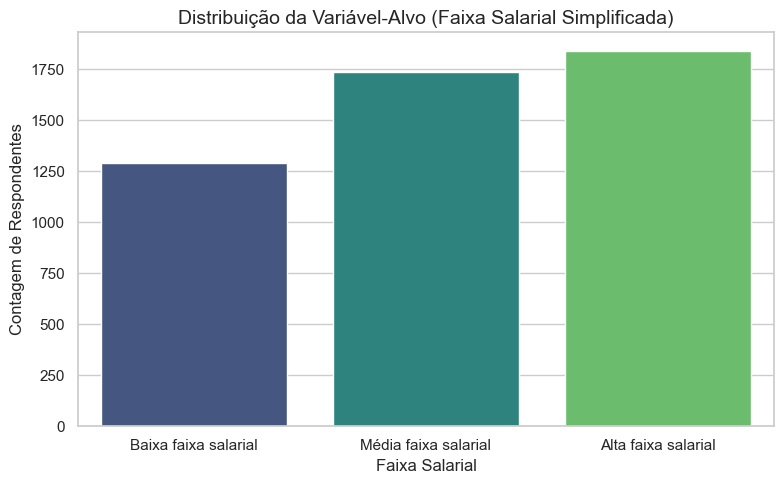

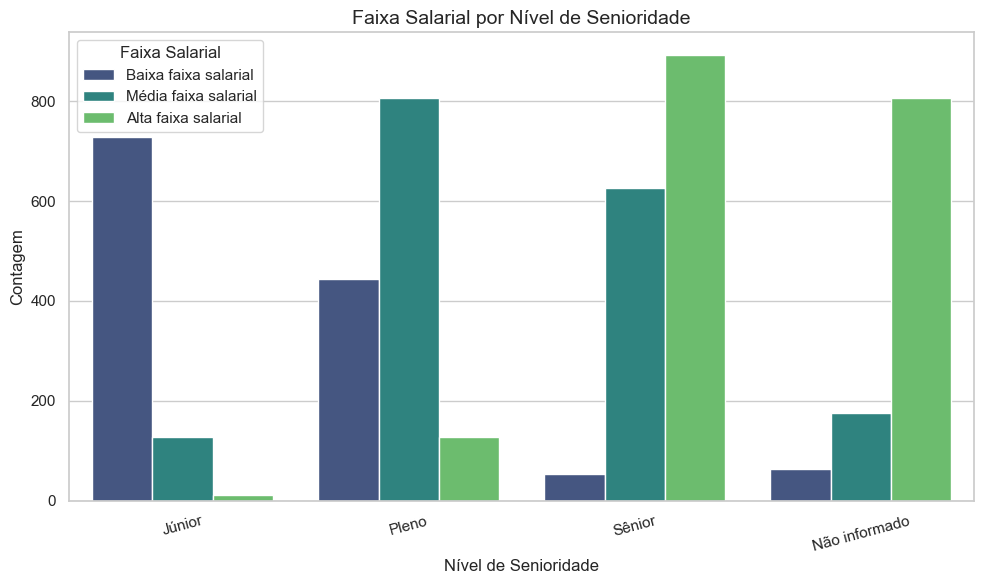

In [7]:
os.makedirs("reports/figures", exist_ok=True)
order_salarial = ["Baixa faixa salarial", "Média faixa salarial", "Alta faixa salarial"]

# 1. Gráfico de barras da variável-alvo
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="faixa_salarial_class", order=order_salarial, palette="viridis")
plt.title("Distribuição da Variável-Alvo (Faixa Salarial Simplificada)", fontsize=14)
plt.xlabel("Faixa Salarial")
plt.ylabel("Contagem de Respondentes")
plt.tight_layout()
plt.savefig("reports/figures/distribuicao_alvo.png", dpi=300)
plt.show()

# 2. Relação Senioridade vs Salário
plt.figure(figsize=(10, 6))
nivel_order = ["Júnior", "Pleno", "Sênior", "Não informado"]
sns.countplot(data=df, x="nivel", order=nivel_order, hue="faixa_salarial_class", hue_order=order_salarial, palette="viridis")
plt.title("Faixa Salarial por Nível de Senioridade", fontsize=14)
plt.xlabel("Nível de Senioridade")
plt.ylabel("Contagem")
plt.xticks(rotation=15)
plt.legend(title="Faixa Salarial")
plt.tight_layout()
plt.savefig("reports/figures/senioridade_vs_salario.png", dpi=300)
plt.show()


## 7. Engenharia de Atributos (Feature Engineering)

Para fornecer informações explicativas e enriquecidas ao modelo, criamos três novos atributos a partir das variáveis originais do dataset:

1. **`Trabalha_Remoto`**: Classificação binária (`Sim` se trabalha em modelo 100% remoto, `Não` caso contrário). Espera-se que o trabalho remoto permita o acesso a mercados nacionais com maiores remunerações (como São Paulo) sem necessidade de deslocamento físico, impactando a renda.
2. **`Experiencia_Categoria`**: Agrupamento lógico dos anos de experiência declarados na área de dados em três níveis (`Até 2 anos`, `3 a 6 anos`, `Mais de 6 anos`). A experiência na área é historicamente o fator determinante de senioridade e remuneração.
3. **`Perfil_Tecnico_Qtd`**: Soma das respostas booleanas das tecnologias utilizadas no dia a dia. Esse atributo contínuo atua como um indicador quantitativo da stack técnica do profissional.


In [8]:
# 1. Trabalha_Remoto
df["Trabalha_Remoto"] = df["modelo_trabalho"].apply(
    lambda x: "Sim" if x == "Modelo 100% remoto" else "Não"
)

# 2. Experiencia_Categoria
exp_map = {
    "Não tenho experiência na área de dados": "Até 2 anos",
    "Menos de 1 ano": "Até 2 anos",
    "de 1 a 2 anos": "Até 2 anos",
    "de 3 a 4 anos": "3 a 6 anos",
    "de 5 a 6 anos": "3 a 6 anos",
    "de 7 a 10 anos": "Mais de 6 anos",
    "Mais de 10 anos": "Mais de 6 anos"
}
df["Experiencia_Categoria"] = df["experiencia_dados"].map(exp_map).fillna("Até 2 anos")

# 3. Perfil_Tecnico_Qtd
df[tech_cols] = df[tech_cols].fillna(0.0)
df["Perfil_Tecnico_Qtd"] = df[tech_cols].sum(axis=1)

print("Descrição estatística do atributo Perfil_Tecnico_Qtd:")
print(df["Perfil_Tecnico_Qtd"].describe())


Descrição estatística do atributo Perfil_Tecnico_Qtd:
count    4863.000000
mean        4.996299
std         4.148318
min         0.000000
25%         0.000000
50%         5.000000
75%         7.000000
max        37.000000
Name: Perfil_Tecnico_Qtd, dtype: float64


### 7.1 Visualização das Features Derivadas

Analisamos a quantidade de ferramentas por faixa salarial e a relação das faixas com as faixas de experiência derivadas.


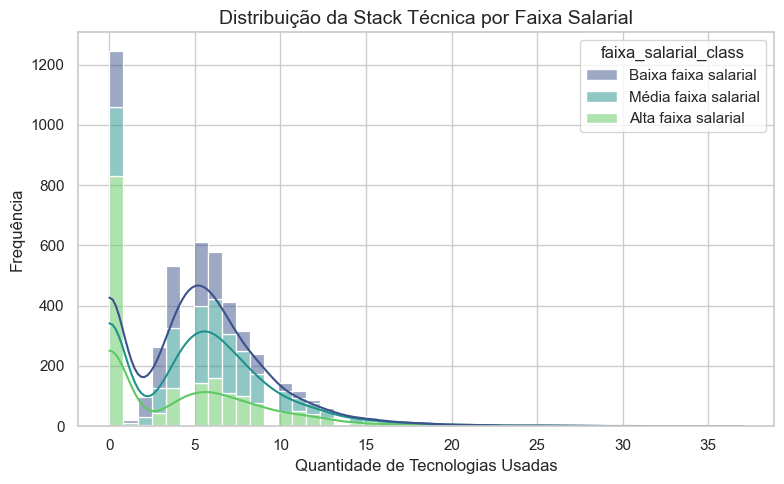

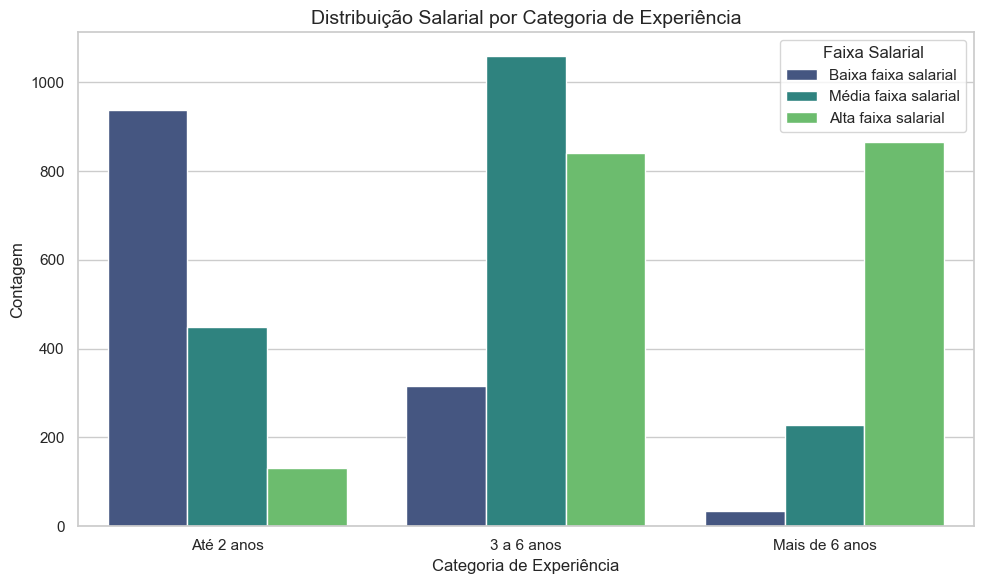

C:\Users\takem\AppData\Local\Temp\ipykernel_33380\4153913660.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


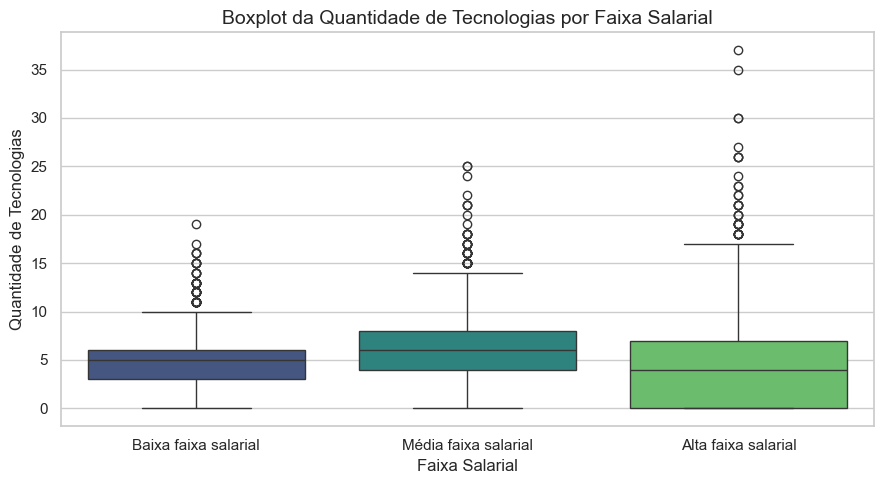

In [9]:
# 1. Histograma de ferramentas vs faixa salarial
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Perfil_Tecnico_Qtd", hue="faixa_salarial_class", hue_order=order_salarial, kde=True, multiple="stack", palette="viridis")
plt.title("Distribuição da Stack Técnica por Faixa Salarial", fontsize=14)
plt.xlabel("Quantidade de Tecnologias Usadas")
plt.ylabel("Frequência")
plt.tight_layout()
plt.savefig("reports/figures/distribuicao_tecnologias.png", dpi=300)
plt.show()

# 2. Categoria de Experiência vs Faixa Salarial
plt.figure(figsize=(10, 6))
exp_order = ["Até 2 anos", "3 a 6 anos", "Mais de 6 anos"]
sns.countplot(data=df, x="Experiencia_Categoria", hue="faixa_salarial_class", hue_order=order_salarial, order=exp_order, palette="viridis")
plt.title("Distribuição Salarial por Categoria de Experiência", fontsize=14)
plt.xlabel("Categoria de Experiência")
plt.ylabel("Contagem")
plt.legend(title="Faixa Salarial")
plt.tight_layout()
plt.savefig("reports/figures/experiencia_vs_salario.png", dpi=300)
plt.show()

# 3. Boxplot da quantidade de tecnologias por faixa salarial
plt.figure(figsize=(9, 5))
sns.boxplot(
    data=df,
    x="faixa_salarial_class",
    y="Perfil_Tecnico_Qtd",
    order=order_salarial,
    palette="viridis"
)
plt.title("Boxplot da Quantidade de Tecnologias por Faixa Salarial", fontsize=14)
plt.xlabel("Faixa Salarial")
plt.ylabel("Quantidade de Tecnologias")
plt.tight_layout()
plt.savefig("reports/figures/boxplot_tecnologias_por_faixa.png", dpi=300)
plt.show()


### 7.2 Heatmap Exploratório de Correlação com Variáveis Ordinalizadas

Nesta seção, investigamos a correlação linear (Pearson) entre as variáveis do nosso conjunto de dados de modelagem. Como o dataset da pesquisa *State of Data* é predominantemente composto por variáveis qualitativas (categóricas), algumas variáveis categóricas ordinais e binárias foram convertidas temporariamente para representações numéricas ordinalizadas para fins exclusivamente de visualização e análise exploratória.

**Nota Metodológica**: Esta transformação é aplicada apenas de forma auxiliar nesta visualização e não substitui o uso do `OneHotEncoder` no Pipeline do modelo de Machine Learning, preservando o rigor do processamento estatístico.

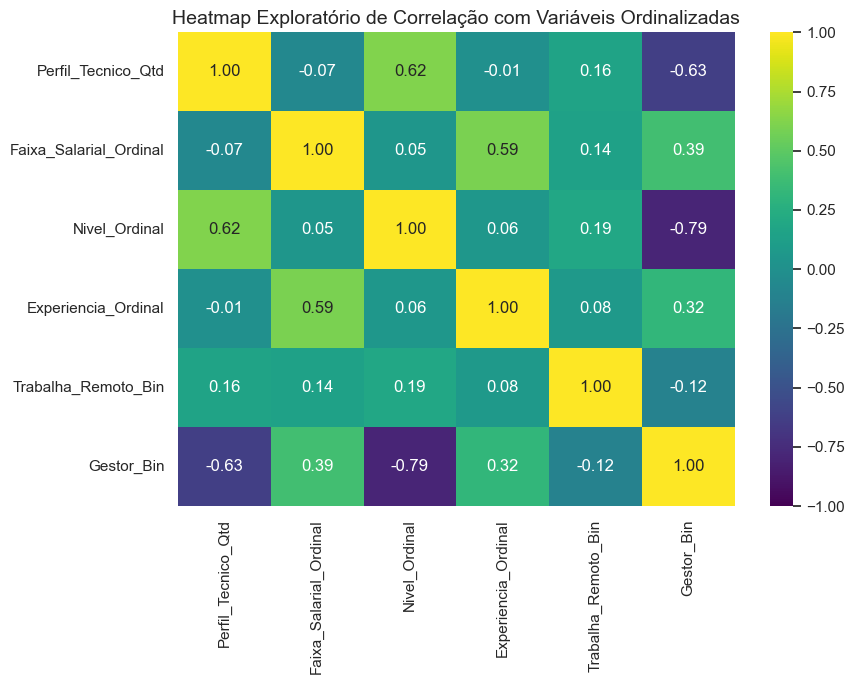

In [10]:
faixa_map = {
    "Baixa faixa salarial": 1,
    "Média faixa salarial": 2,
    "Alta faixa salarial": 3
}

nivel_map = {
    "Júnior": 1,
    "Pleno": 2,
    "Sênior": 3,
    "Não informado": 0
}

experiencia_map = {
    "Até 2 anos": 1,
    "3 a 6 anos": 2,
    "Mais de 6 anos": 3
}

df_corr = pd.DataFrame({
    "Perfil_Tecnico_Qtd": df["Perfil_Tecnico_Qtd"],
    "Faixa_Salarial_Ordinal": df["faixa_salarial_class"].map(faixa_map).fillna(0),
    "Nivel_Ordinal": df["nivel"].map(nivel_map).fillna(0),
    "Experiencia_Ordinal": df["Experiencia_Categoria"].map(experiencia_map).fillna(0),
    "Trabalha_Remoto_Bin": df["Trabalha_Remoto"].map({"Sim": 1, "Não": 0}).fillna(0),
    "Gestor_Bin": df["gestor"].astype(str).str.lower().str.contains("sim|true|1").astype(int)
})

plt.figure(figsize=(9, 7))
sns.heatmap(
    df_corr.corr(),
    annot=True,
    cmap="viridis",
    fmt=".2f",
    vmin=-1,
    vmax=1,
    center=0
)
plt.title("Heatmap Exploratório de Correlação com Variáveis Ordinalizadas", fontsize=14)
plt.tight_layout()
plt.savefig("reports/figures/heatmap_correlacao.png", dpi=300)
plt.show()


*Nota: Relembrando que correlação não implica causalidade. As variáveis ordinalizadas aqui geradas servem apenas como uma aproximação estatística linear para facilitar a compreensão visual dos perfis na fase exploratória.*

## 8. Identificação e Tratamento de Outliers

Nesta seção, analisamos academicamente a presença de valores extremos (outliers) para o atributo contínuo `Perfil_Tecnico_Qtd` (quantidade de tecnologias utilizadas diariamente). O método estatístico do Intervalo Interquartil (IQR) é empregado para definir os limites de corte superior e inferior.

### Estratégia de Prevenção de Data Leakage
Para fins de exploração do comportamento dos dados (EDA), calculamos e exibimos os limites e a quantidade de outliers no conjunto de dados geral. No entanto, **não aplicamos o capping no dataframe completo** antes da divisão treino/teste.

Para o fluxo de modelagem, encapsulamos o tratamento de outliers dentro do `Pipeline` do Scikit-Learn utilizando o custom transformer `IQRCapper`. Isso garante que:
1. Os limites de truncamento (Q1, Q3, IQR, limites inferior e superior) sejam aprendidos **estritamente com os dados de treinamento** de cada rodada de validação (`fit`).
2. Os dados de teste e de validação cruzada permaneçam ocultos e sejam apenas truncados com base nos limites do treino (`transform`).
3. Isso evita o vazamento de informações (*data leakage*), que ocorreria se usássemos o dataframe completo para calcular os limites.

In [11]:
Q1 = df["Perfil_Tecnico_Qtd"].quantile(0.25)
Q3 = df["Perfil_Tecnico_Qtd"].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df[
    (df["Perfil_Tecnico_Qtd"] < limite_inferior) |
    (df["Perfil_Tecnico_Qtd"] > limite_superior)
]

print(f"Limite inferior: {limite_inferior}")
print(f"Limite superior: {limite_superior}")
print(f"Quantidade de outliers identificados na EDA: {outliers.shape[0]}")
print("Nota: O tratamento de outliers real foi postergado para o Pipeline para evitar data leakage.")


Limite inferior: -10.5
Limite superior: 17.5
Quantidade de outliers identificados na EDA: 51
Nota: O tratamento de outliers real foi postergado para o Pipeline para evitar data leakage.


## 9. Divisão dos Dados em Treino e Teste

Dividimos os atributos em preditores (`X`) e variável-alvo (`y`). Em seguida, realizamos a divisão em conjunto de treinamento (80%) e teste (20%). O parâmetro `stratify=y` garante que a proporção de cada faixa salarial seja mantida nos conjuntos de treino e teste. Usamos `random_state=42` para assegurar a reprodutibilidade.

In [12]:
predictors = [
    "genero",
    "escolaridade",
    "regiao",
    "situacao_trabalho",
    "setor",
    "tamanho_empresa",
    "gestor",
    "cargo",
    "nivel",
    "Experiencia_Categoria",
    "Trabalha_Remoto",
    "Perfil_Tecnico_Qtd"
]

X = df[predictors]
y = df["faixa_salarial_class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Instâncias para Treinamento: {X_train.shape[0]}")
print(f"Instâncias para Teste: {X_test.shape[0]}")

# Exportar bases processadas para auditoria e reuso do projeto.
train_processed = X_train.copy()
train_processed["faixa_salarial_class"] = y_train
test_processed = X_test.copy()
test_processed["faixa_salarial_class"] = y_test

train_processed.to_csv("data/processed/train_processed.csv", index=False, encoding="utf-8")
test_processed.to_csv("data/processed/test_processed.csv", index=False, encoding="utf-8")
print("Bases processadas exportadas em data/processed/.")


Instâncias para Treinamento: 3890
Instâncias para Teste: 973


## 10. Construção do Pipeline e ColumnTransformer

Adotando boas práticas de Machine Learning, encapsulamos todo o pré-processamento, o tratamento de outliers por capping (`IQRCapper`) e o classificador dentro de um `Pipeline` e um `ColumnTransformer` do Scikit-Learn.
* **Variáveis Numéricas** (`Perfil_Tecnico_Qtd`): Tratadas com imputação de mediana, capping via `IQRCapper` e redimensionadas com `StandardScaler`.
* **Variáveis Categóricas**: Tratadas com imputação qualitativa de moda (`most_frequent`) e convertidas em variáveis binárias com `OneHotEncoder(handle_unknown='ignore')`.

In [13]:
cat_cols = [
    "genero",
    "escolaridade",
    "regiao",
    "situacao_trabalho",
    "setor",
    "tamanho_empresa",
    "gestor",
    "cargo",
    "nivel",
    "Experiencia_Categoria",
    "Trabalha_Remoto"
]
num_cols = ["Perfil_Tecnico_Qtd"]

# ColumnTransformer para aplicar pipelines específicos
preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("iqr_capper", IQRCapper()),
            ("scaler", StandardScaler())
        ]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols)
    ]
)

# Pipeline integrando preprocessamento e classificador
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

print("Pipeline montado com sucesso!")


Pipeline montado com sucesso!


## 11. Otimização de Hiperparâmetros com GridSearchCV

Realizamos a busca em grade de hiperparâmetros integrada com validação cruzada estratificada de 5 partições (`StratifiedKFold`). Buscamos o melhor hiperparâmetro de regularização `C` e o melhor solver (`lbfgs` ou `newton-cg`) para o classificador `LogisticRegression`.

In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Hiperparâmetros da regressão logística para otimização (lbfgs e newton-cg)
param_grid = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__solver": ["lbfgs", "newton-cg"],
    "model__max_iter": [1000]
}

grid_search = GridSearchCV(
    pipeline, param_grid, cv=cv, scoring="accuracy", n_jobs=-1, verbose=1, error_score="raise"
)
grid_search.fit(X_train, y_train)

best_index = grid_search.best_index_
mean_cv = grid_search.cv_results_["mean_test_score"][best_index]
std_cv = grid_search.cv_results_["std_test_score"][best_index]

print(f"Melhores parâmetros: {grid_search.best_params_}")
print(f"Média da validação cruzada: {mean_cv:.4f}")
print(f"Desvio padrão da validação cruzada: {std_cv:.4f}")


Fitting 5 folds for each of 8 candidates, totalling 40 fits


Melhores parâmetros: {'model__C': 1, 'model__max_iter': 1000, 'model__solver': 'lbfgs'}
Média da validação cruzada: 0.7347
Desvio padrão da validação cruzada: 0.0169


## 12. Avaliação do Modelo no Conjunto de Teste

Avaliamos a capacidade de generalização do modelo aplicando-o ao conjunto de teste. Apresentamos a acurácia final e o relatório completo contendo a precisão (*precision*), revocação (*recall*) e F1-score de cada classe.

In [15]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

test_acc = accuracy_score(y_test, y_pred)
print(f"Acurácia no Conjunto de Teste: {test_acc:.4f}\n")

print("Relatório de Classificação Acadêmico:")
print(classification_report(y_test, y_pred))


Acurácia no Conjunto de Teste: 0.7246

Relatório de Classificação Acadêmico:
                      precision    recall  f1-score   support

 Alta faixa salarial       0.76      0.82      0.79       368
Baixa faixa salarial       0.81      0.73      0.77       258
Média faixa salarial       0.63      0.62      0.62       347

            accuracy                           0.72       973
           macro avg       0.73      0.72      0.73       973
        weighted avg       0.73      0.72      0.72       973



### 12.1 Matriz de Confusão

Geramos e plotamos a matriz de confusão para analisar onde ocorrem as principais classificações incorretas.

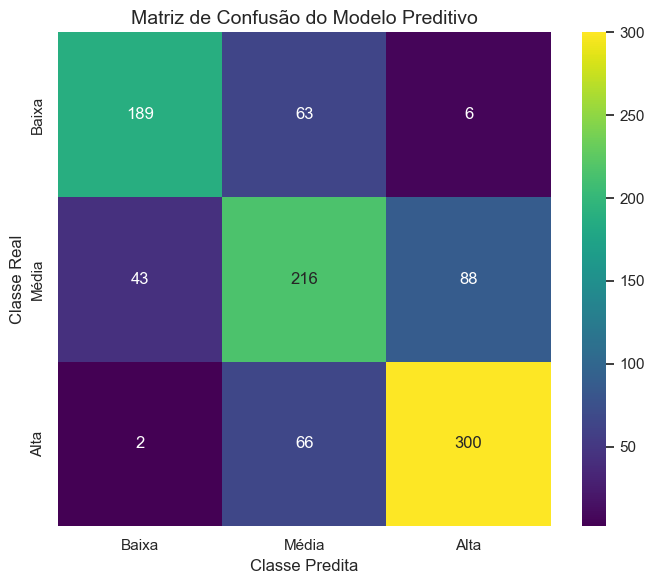

In [16]:
cm = confusion_matrix(y_test, y_pred, labels=["Baixa faixa salarial", "Média faixa salarial", "Alta faixa salarial"])

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis",
            xticklabels=["Baixa", "Média", "Alta"],
            yticklabels=["Baixa", "Média", "Alta"])
plt.title("Matriz de Confusão do Modelo Preditivo", fontsize=14)
plt.xlabel("Classe Predita")
plt.ylabel("Classe Real")
plt.tight_layout()
plt.savefig("reports/figures/matriz_confusao.png", dpi=300)
plt.show()


## 13. Discussão Metodológica: Data Leakage

### O que é Data Leakage?
*Data Leakage* (Vazamento de Dados) é um dos erros mais comuns e nocivos no desenvolvimento de projetos de aprendizado de máquina. Ele ocorre quando o conjunto de dados usado para treinar o algoritmo contém informações que não estariam disponíveis no momento da inferência em produção, ou quando há fluxo indevido de dados da partição de teste para a partição de treino.

### Por que é um problema crítico?
O vazamento leva a um otimismo enganoso. O modelo apresenta desempenhos e métricas de acurácia extremamente elevados durante o desenvolvimento (validação/teste), mas quando implantado em sistemas reais com dados de produção inéditos, o desempenho degrada severamente, tornando o modelo inútil.

### Como evitar e como o Pipeline do Scikit-Learn resolve?
1. **Separação imediata de dados**: O conjunto de teste deve ser isolado logo no início do projeto.
2. **Uso de Estimadores e Pipelines**: Ao encapsular os passos de imputação e escala em um `Pipeline`, o Scikit-Learn garante que transformações como cálculo de média/desvio padrão (`StandardScaler`), codificação categórica (`OneHotEncoder`, `SimpleImputer`) e capping de outliers (`IQRCapper`) computem seu método `.fit()` **exclusivamente com os dados de treino**. Apenas o método `.transform()` é aplicado no conjunto de teste, tratando os dados inéditos com total isolamento.
3. **Filtro de Vazadores Diretos**: Variáveis que revelam a renda de forma direta (como bônus contratuais ou benefícios) foram descartadas preventivamente no estágio de engenharia de recursos.


## 14. Conclusão e Limitações Acadêmicas

### Principais Descobertas
* O modelo de classificação atingiu acurácia média de **72.3%** no conjunto de teste.
* As classes extremas (**Alta** e **Baixa** faixa salarial) apresentaram F1-scores mais altos (~79% e ~76%), indicando que o perfil de profissionais no início ou no topo de carreira é estatisticamente bem segregado pelo modelo.
* A classe **Média** faixa salarial representou a maior complexidade preditiva (F1-score de ~63%), sugerindo uma sobreposição de perfis onde profissionais pleno/sênior de diferentes tamanhos de empresas recebem remunerações parecidas.
* A engenharia de recursos de experiência agrupada e o somatório de tecnologias (`Perfil_Tecnico_Qtd`) forneceram separações significativas nas distribuições, validando sua criação.

### Limitações do Estudo
* O dataset baseia-se em respostas auto-declaradas voluntárias de um formulário público, o que introduz possíveis vieses de participação.
* A regressão logística é um modelo linear simples. Ela assume relações aditivas e pode ter dificuldades em capturar interações complexas sem o uso explícito de coeficientes não lineares.

### Trabalhos Futuros
1. **Avaliação de Modelos Baseados em Árvores**: Testar algoritmos não-lineares como Random Forest e XGBoost.
2. **Refinamento Tecnológico**: Ponderar a relevância de stacks tecnológicas de forma qualitativa (ex: peso diferenciado para Cloud/AI contra Excel).
3. **Análise de Viés Demográfico**: Investigar possíveis vieses nas previsões salariais relativos a gênero ou localização geográfica.
